# L12 - MLP with Keras


In [1]:

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from time import strftime


## 1. Load Dataset (Fashion-MNIST)

In [2]:
from tensorflow.keras.datasets import fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()


In [3]:
# Split training data into training and vvalidation sets - skiped since we are using validation_split

#X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
#y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

# Normalize pixel values to range [0, 1]
X_test = X_test / 255.0
X_train = X_train_full / 255.0
y_train = y_train_full

## 2. Visualize sample images

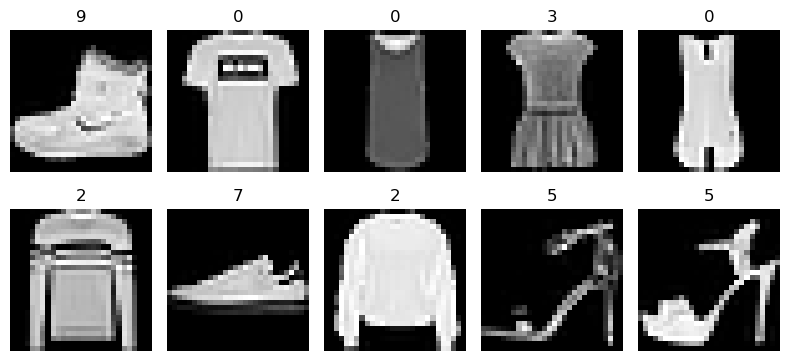

In [4]:
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
    plt.tight_layout()
plt.show()

### Task on dataset:
- T2.a) Replace the numeric labels with class names
The numeric labels are replaced with class names merely using the already defined indices as shown below.

In [5]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

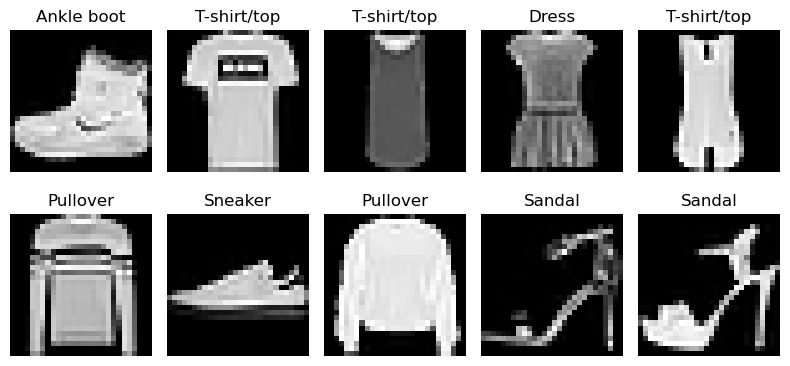

In [6]:
# T2.a: Replace with Class names
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[int(y_train[i])])  # <- map 0-9 to name
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Build a basic MLP Model

In [25]:

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


## 4. Compile Model (Try SGD vs Adam)

In [26]:

model.compile(
    #optimizer='adam',  # TODO: try 'adam'
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Callbacks

In [27]:

log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]


## 6. Train Model

In [28]:

history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7143 - loss: 0.9049 - val_accuracy: 0.7965 - val_loss: 0.6201
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8102 - loss: 0.5692 - val_accuracy: 0.8134 - val_loss: 0.5368
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8262 - loss: 0.5051 - val_accuracy: 0.8347 - val_loss: 0.4880
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8366 - loss: 0.4728 - val_accuracy: 0.8378 - val_loss: 0.4662
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8438 - loss: 0.4495 - val_accuracy: 0.8426 - val_loss: 0.4507
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8491 - loss: 0.4337 - val_accuracy: 0.8488 - val_loss: 0.4333
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8534 - loss: 0.4201 - val_accuracy: 0.8532 - val_loss: 0.4230
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8570 - loss: 0.4101 - val_accuracy: 0.

## 7. Plot Learning Curves

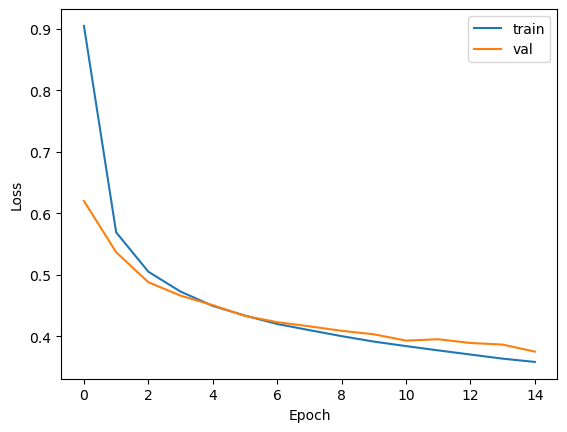

In [29]:

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## 8. Tasks and questions on the MLP model

### T8.a) Plot accuracy curves as well

The accuracy curve is plotted based on the already stored data for accuracy in history.


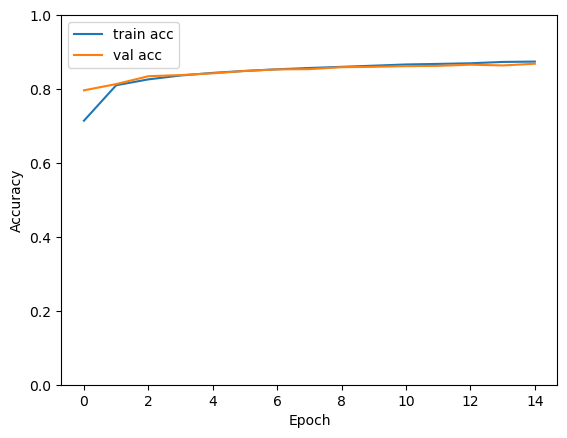

In [30]:
# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.show()

### T8.b) Analyze TensorBoard logs

Opening the Tensorboard provides the following epoc-accuracy plot 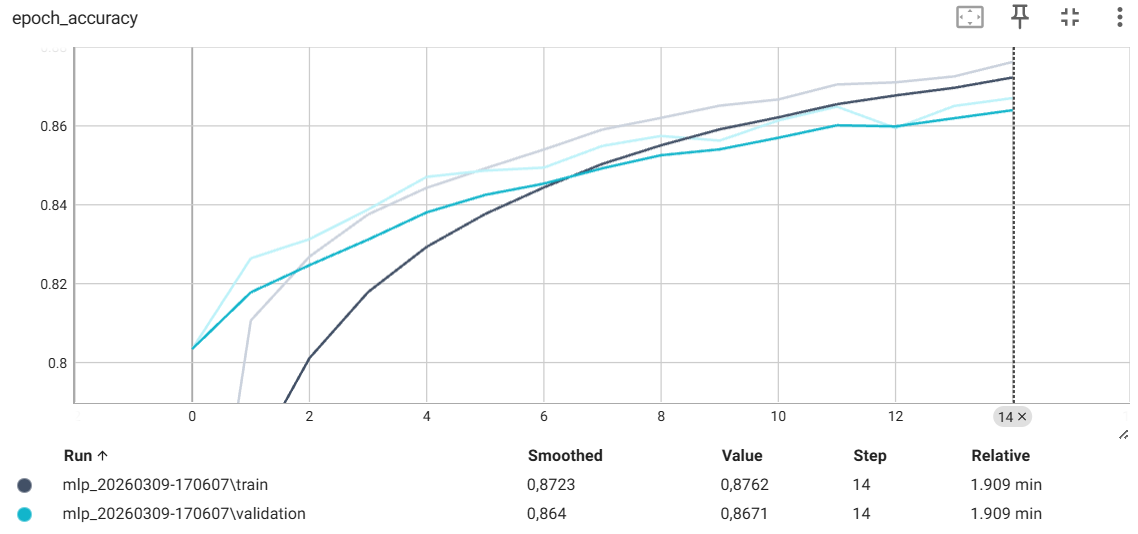 From which it can be seen that the model learns steadily and that the validation closely tracks the training of the alogrithm as is desired. There is also no strong signs of overfitting and the performance can in general be considered decent. Adjusting the smoothness results in a similar result except for there being more spikes, especially in the validation results, in the curves, along with the overall end position being closer together for higher smoothness, the above plot is from 0.6 smoothness.

We furthmore test what happens when the learning rate is changed to 0.001 and the optimizer is changed to Adam.

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4975 - loss: 1.7369 - val_accuracy: 0.6471 - val_loss: 1.3361
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6598 - loss: 1.1556 - val_accuracy: 0.6862 - val_loss: 1.0060
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6956 - loss: 0.9395 - val_accuracy: 0.7147 - val_loss: 0.8676
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7233 - loss: 0.8363 - val_accuracy: 0.7420 - val_loss: 0.7905
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7456 - loss: 0.7730 - val_accuracy: 0.7598 - val_loss: 0.7396
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7617 - loss: 0.7282 - val_accuracy: 0.7702 - val_loss: 0.7019
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7751 - loss: 0.6931 - val_accuracy: 0.7808 - val_loss: 0.6706
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7851 - loss: 0.6644 - val_accuracy: 0.

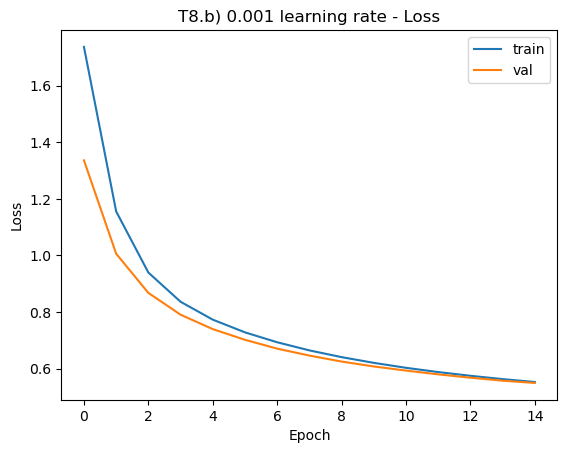

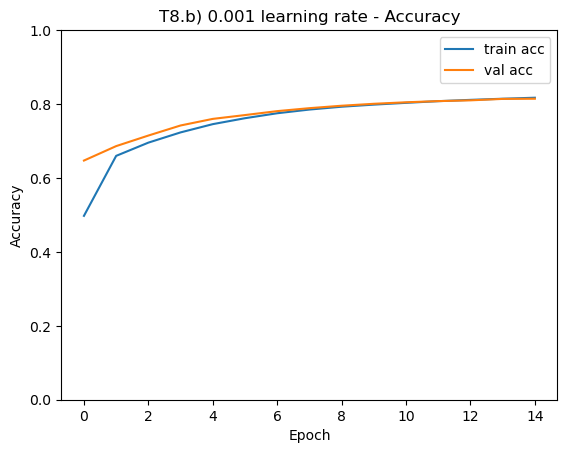

In [22]:
## T8. b - Learning rate of 0.001
model_small = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

#The learning rate is changed here
model_small.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = "logs/mlp_0.001_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history_small = model_small.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history_small.history['loss'], label='train')
plt.plot(history_small.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.b) 0.001 learning rate - Loss')
plt.show()

plt.figure()
plt.plot(history_small.history['accuracy'], label='train acc')
plt.plot(history_small.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.b) 0.001 learning rate - Accuracy')
plt.show()

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4220 - loss: 1.8895 - val_accuracy: 0.6438 - val_loss: 1.4757
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6613 - loss: 1.2551 - val_accuracy: 0.6945 - val_loss: 1.0638
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7023 - loss: 0.9794 - val_accuracy: 0.7268 - val_loss: 0.8861
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7340 - loss: 0.8507 - val_accuracy: 0.7497 - val_loss: 0.7934
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7558 - loss: 0.7754 - val_accuracy: 0.7686 - val_loss: 0.7342
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7711 - loss: 0.7232 - val_accuracy: 0.7824 - val_loss: 0.6915
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7829 - loss: 0.6843 - val_accuracy: 0.7865 - val_loss: 0.6596
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7900 - loss: 0.6540 - val_accuracy: 0.

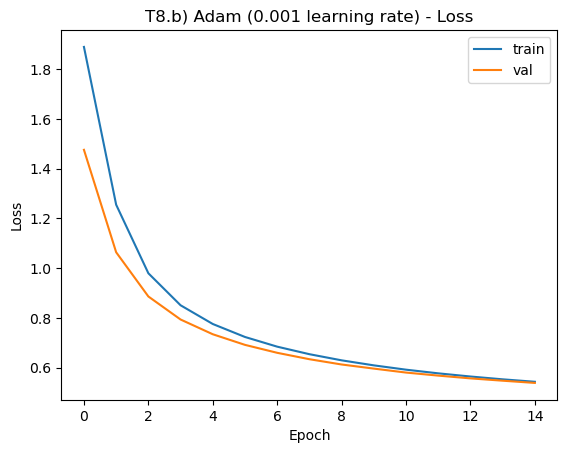

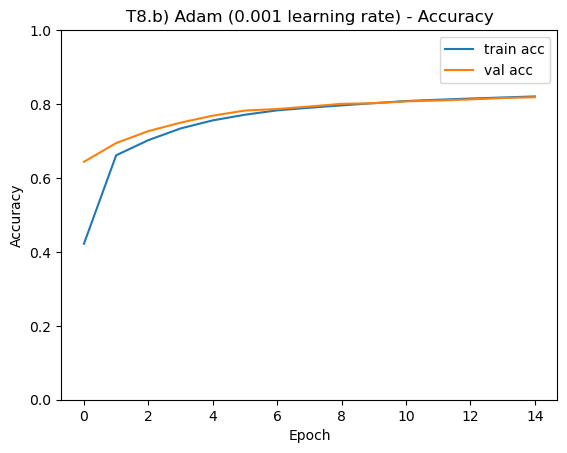

In [21]:
## T8. b - Adam
model_adam = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

#The learning rate is changed here
model_adam.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = "logs/mlp_adam_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history_adam = model_adam.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history_adam.history['loss'], label='train')
plt.plot(history_adam.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.b) Adam (0.001 learning rate) - Loss')
plt.show()

plt.figure()
plt.plot(history_adam.history['accuracy'], label='train acc')
plt.plot(history_adam.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.b) Adam (0.001 learning rate) - Accuracy')
plt.show()

## Additional tasks on the MLP model to optimize model accuracy
### T8.c) Experiment with more training epochs.

To see what more training epocs does, it is increased from 15 to 70, see code below. We note that early stopping occurred at 55.



Epoch 1/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7149 - loss: 0.9086 - val_accuracy: 0.7876 - val_loss: 0.6234
Epoch 2/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8064 - loss: 0.5736 - val_accuracy: 0.8150 - val_loss: 0.5359
Epoch 3/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8257 - loss: 0.5077 - val_accuracy: 0.8274 - val_loss: 0.4859
Epoch 4/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8358 - loss: 0.4752 - val_accuracy: 0.8336 - val_loss: 0.4726
Epoch 5/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8432 - loss: 0.4539 - val_accuracy: 0.8405 - val_loss: 0.4640
Epoch 6/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8481 - loss: 0.4372 - val_accuracy: 0.8479 - val_loss: 0.4323
Epoch 7/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8525 - loss: 0.4243 - val_accuracy: 0.8476 - val_loss: 0.4323
Epoch 8/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8574 - loss: 0.4116 - val_accuracy: 0.

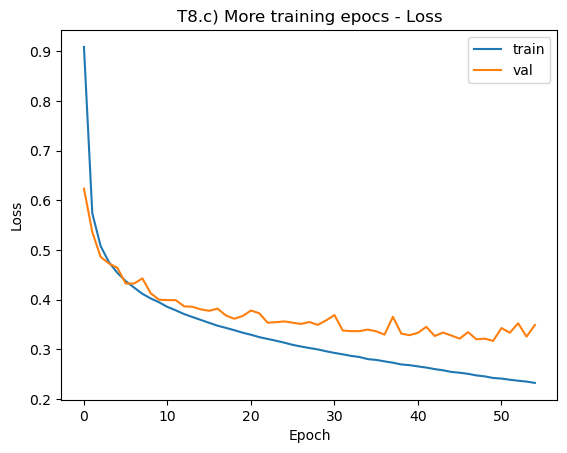

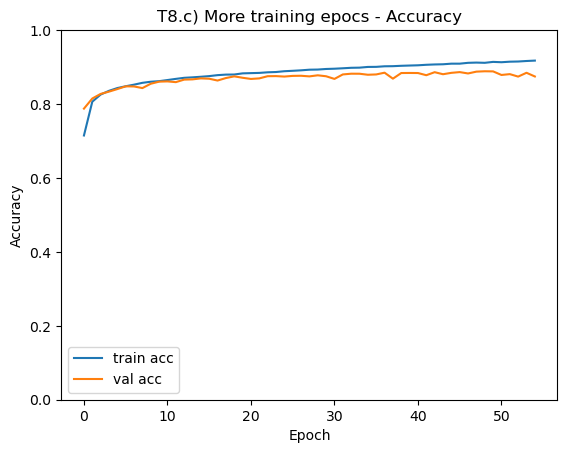

In [23]:
## T8. c - More training epochs
model2 = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model2.compile(
    #optimizer='adam',  # TODO: try 'adam'
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = "logs/mlp_70_epochs_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]
# Increases epochs from 15 to 30
history2 = model2.fit(
    X_train, y_train,
    epochs=70,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history2.history['loss'], label='train')
plt.plot(history2.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.c) More training epocs - Loss')
plt.show()

plt.figure()
plt.plot(history2.history['accuracy'], label='train acc')
plt.plot(history2.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.c) More training epocs - Accuracy')
plt.show()

### T8.d) Add a third hidden layer and train the model

We add another hidden layer of 64 neurons. The epochs is set back to 15.

From the results it can be seen that the accuracy is slighly higher and the loss a bit lower but it is not a large improvement in this case.

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6990 - loss: 0.9306 - val_accuracy: 0.7919 - val_loss: 0.6159
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8086 - loss: 0.5617 - val_accuracy: 0.8162 - val_loss: 0.5159
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8266 - loss: 0.4956 - val_accuracy: 0.8276 - val_loss: 0.4805
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8390 - loss: 0.4606 - val_accuracy: 0.8448 - val_loss: 0.4445
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8479 - loss: 0.4370 - val_accuracy: 0.8491 - val_loss: 0.4308
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8535 - loss: 0.4173 - val_accuracy: 0.8497 - val_loss: 0.4376
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8591 - loss: 0.4022 - val_accuracy: 0.8533 - val_loss: 0.4122
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8627 - loss: 0.3917 - val_accuracy: 0.

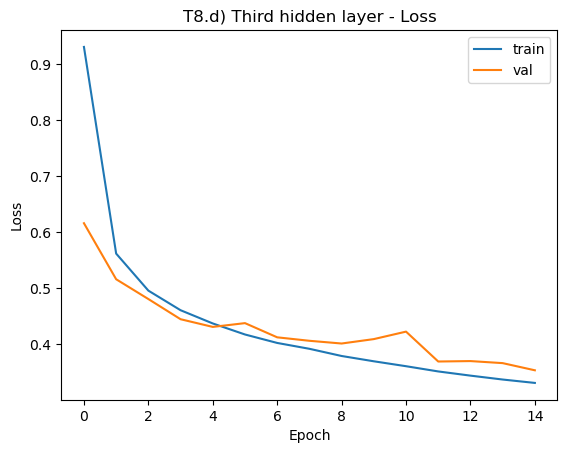

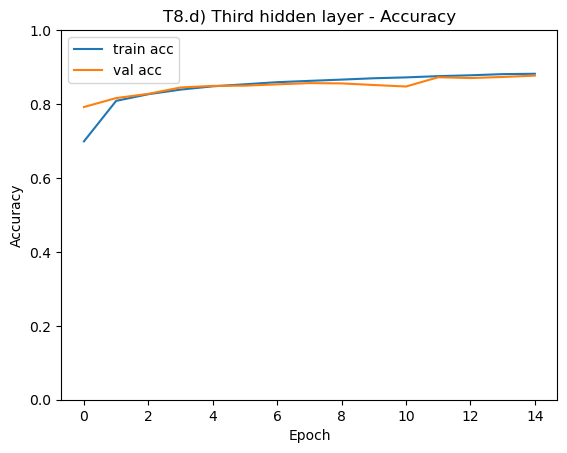

In [12]:
# T8.d) - A third hidden layer

#We add a extra layer here consisting of 64 neurons
model3 = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),  #Extra layer
    Dense(10, activation='softmax')
])
model3.compile(
    #optimizer='adam',  # TODO: try 'adam'
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = "logs/mlp_extra_layer_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history3 = model3.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history3.history['loss'], label='train')
plt.plot(history3.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.d) Third hidden layer - Loss')
plt.show()

plt.figure()
plt.plot(history3.history['accuracy'], label='train acc')
plt.plot(history3.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.d) Third hidden layer - Accuracy')
plt.show()

### T8.e) Experiment with different numbers of neurons

To further understand the effect of the neurons we try to increase the neurons to 512 -> 256 -> 128.

Compaed to the test from T8.d) this only resulted in a minimal improvement in accuracy and loss. See the code below

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7298 - loss: 0.8700 - val_accuracy: 0.7980 - val_loss: 0.5937
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8194 - loss: 0.5280 - val_accuracy: 0.8224 - val_loss: 0.4966
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8357 - loss: 0.4745 - val_accuracy: 0.8342 - val_loss: 0.4764
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8445 - loss: 0.4458 - val_accuracy: 0.8474 - val_loss: 0.4433
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8509 - loss: 0.4226 - val_accuracy: 0.8503 - val_loss: 0.4176
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8586 - loss: 0.4052 - val_accuracy: 0.8558 - val_loss: 0.4132
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8617 - loss: 0.3926 - val_accuracy: 0.8577 - val_loss: 0.3987
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8668 - loss: 0.3792 - val_accuracy: 0.

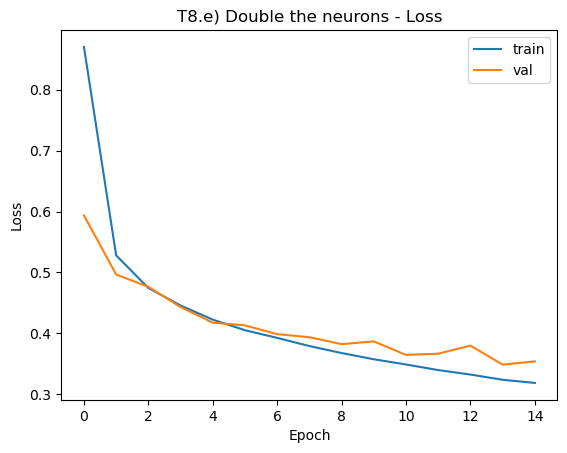

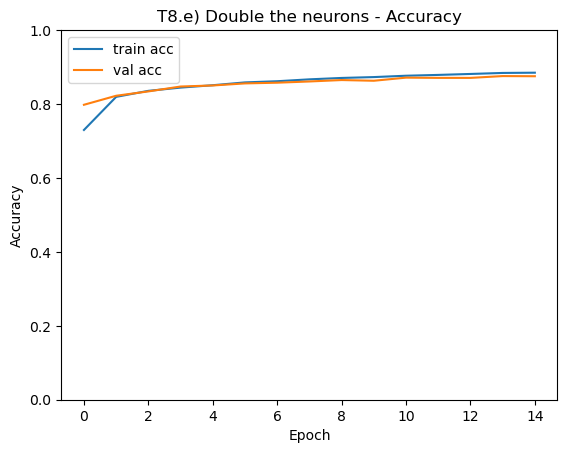

In [13]:
# T8.e) - Different numbers of neurons

#We cnahge the numbers of neurons
model4 = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),  #Extra layer
    Dense(10, activation='softmax')
])
model4.compile(
    #optimizer='adam',  # TODO: try 'adam'
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = "logs/mlp_extra_neurons_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history4 = model4.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history4.history['loss'], label='train')
plt.plot(history4.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.e) Double the neurons - Loss')
plt.show()

plt.figure()
plt.plot(history4.history['accuracy'], label='train acc')
plt.plot(history4.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.e) Double the neurons - Accuracy')
plt.show()

### T8.f) Try other activation functions (e.g. tanh, elu) - explain the functions

We try with both tanh and elu. Previously we used ReLu which sets negative values to 0 and maintains positive values.

The tanh function is the hyperbolic tangent, which maps the input to a value between -1 and 1.

The elu function is the exponential linear unit function which, like ReLu, keeps positive values but gives a smooth negative curve. This can be useful if differentiation is required.

For comparison the model with an extra hidden layer is run. The results can be seen below for the elu and tanh function but comparison is done in Tensorboard resulting in the following curves for accuracy.
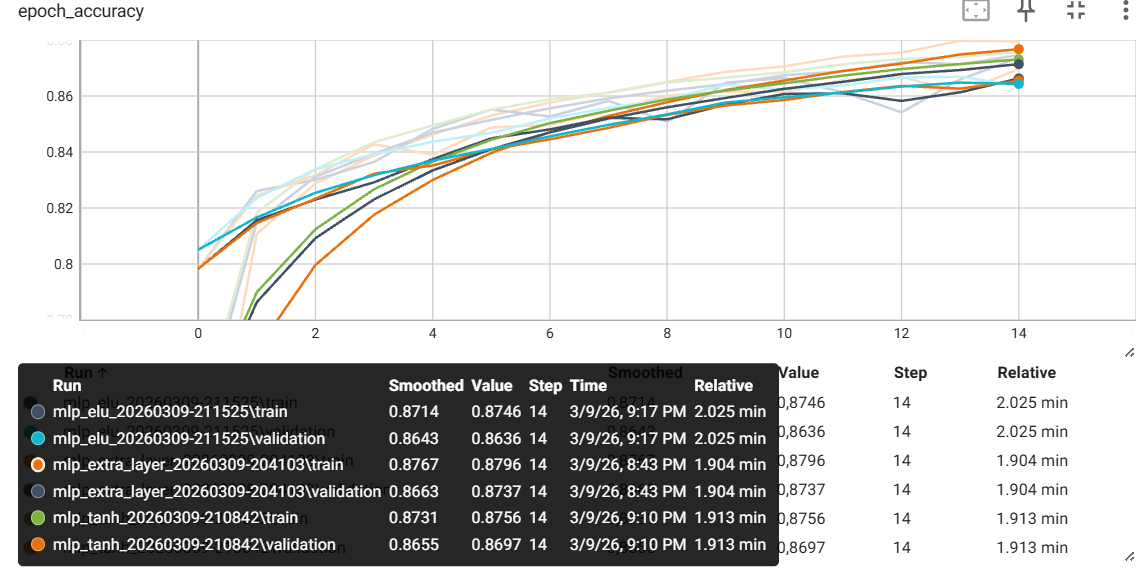

In [14]:
# T8. f) Other activation functions

#We define a function to build the models
def build_model(activation):
    model = Sequential([
        tf.keras.Input(shape=(28, 28)),
        Flatten(),
        Dense(256, activation=activation),
        Dense(128, activation=activation),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7355 - loss: 0.8356 - val_accuracy: 0.7980 - val_loss: 0.5971
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8145 - loss: 0.5414 - val_accuracy: 0.8207 - val_loss: 0.5056
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8310 - loss: 0.4814 - val_accuracy: 0.8312 - val_loss: 0.4680
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8411 - loss: 0.4501 - val_accuracy: 0.8407 - val_loss: 0.4436
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8468 - loss: 0.4287 - val_accuracy: 0.8426 - val_loss: 0.4320
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8532 - loss: 0.4137 - val_accuracy: 0.8484 - val_loss: 0.4142
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8567 - loss: 0.4009 - val_accuracy: 0.8527 - val_loss: 0.4095
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8599 - loss: 0.3909 - val_accuracy: 0.

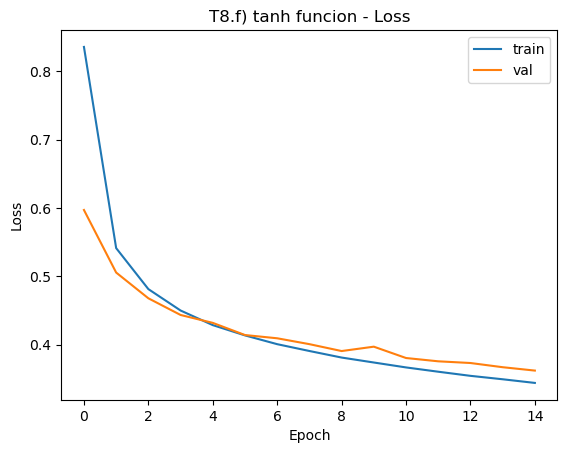

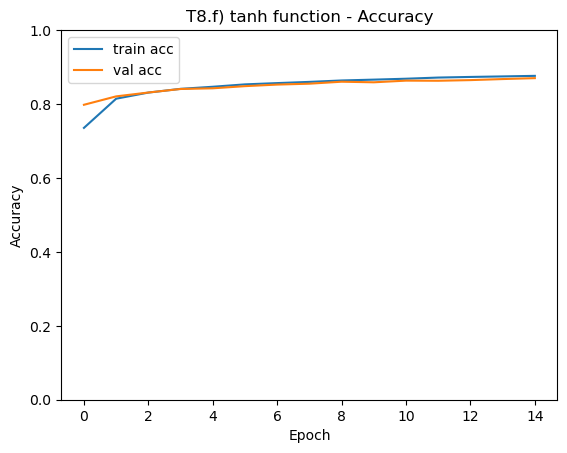

In [15]:
#The tanh model
model_tanh = build_model('tanh')

log_dir = "logs/mlp_tanh_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history_tanh = model_tanh.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history_tanh.history['loss'], label='train')
plt.plot(history_tanh.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.f) tanh funcion - Loss')
plt.show()

plt.figure()
plt.plot(history_tanh.history['accuracy'], label='train acc')
plt.plot(history_tanh.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.f) tanh function - Accuracy')
plt.show()

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7376 - loss: 0.7828 - val_accuracy: 0.8032 - val_loss: 0.5614
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8179 - loss: 0.5227 - val_accuracy: 0.8201 - val_loss: 0.4979
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8325 - loss: 0.4762 - val_accuracy: 0.8282 - val_loss: 0.4735
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8415 - loss: 0.4508 - val_accuracy: 0.8351 - val_loss: 0.4589
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8457 - loss: 0.4349 - val_accuracy: 0.8399 - val_loss: 0.4420
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8509 - loss: 0.4200 - val_accuracy: 0.8481 - val_loss: 0.4238
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8561 - loss: 0.4080 - val_accuracy: 0.8500 - val_loss: 0.4257
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8590 - loss: 0.3988 - val_accuracy: 0.

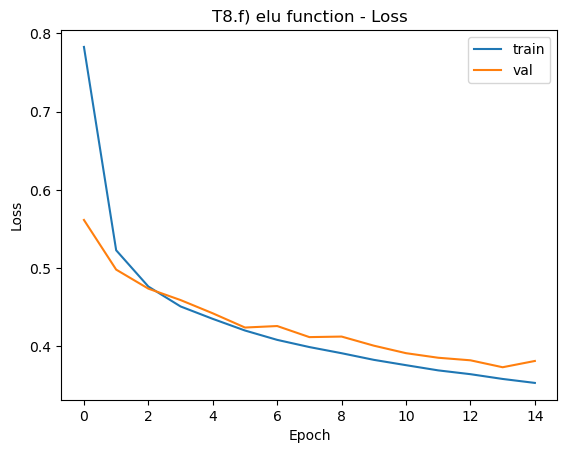

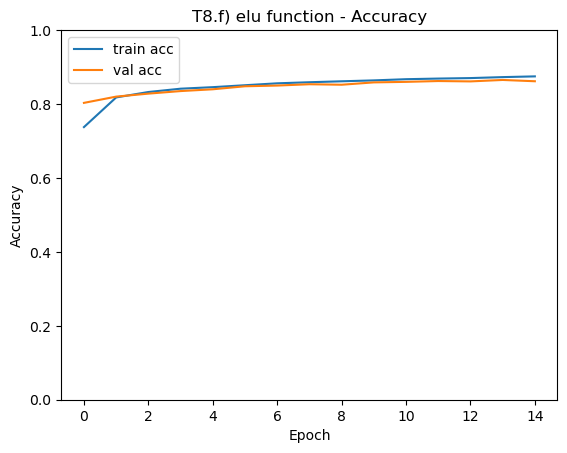

In [16]:
#The elu model
model_elu = build_model('elu')

log_dir = "logs/mlp_elu_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history_elu = model_elu.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history_elu.history['loss'], label='train')
plt.plot(history_elu.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.f) elu function - Loss')
plt.show()

plt.figure()
plt.plot(history_elu.history['accuracy'], label='train acc')
plt.plot(history_elu.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.f) elu function - Accuracy')
plt.show()

### T8.g) Add dropout layers and compare training results

Dropout means that we randomly turns of a certain amount of the neurons during training. In this case we choose to use a dropout rate of 0.3. The model is built below where we continue with the hidden layer version. The compariosn is done in TensorBoard and shown on the following picture. 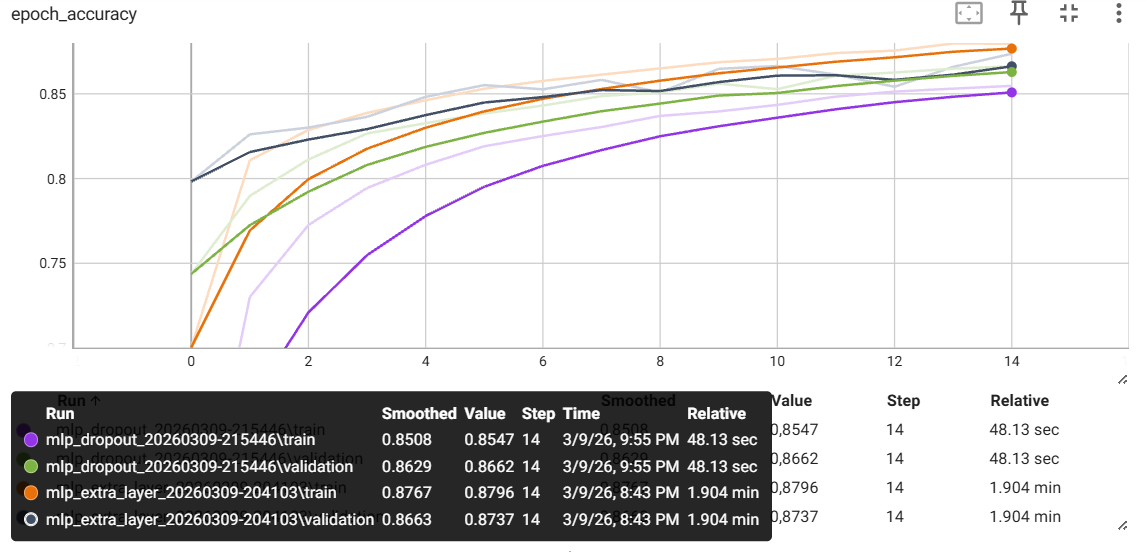 Where we can see that the training accuracy has dropped but the validation accuracy is almost the same and is actually higher than the training accuracy, which is the opposite compared to the standard model.


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5652 - loss: 1.2292 - val_accuracy: 0.7553 - val_loss: 0.6854
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7331 - loss: 0.7372 - val_accuracy: 0.7933 - val_loss: 0.5691
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7709 - loss: 0.6372 - val_accuracy: 0.8197 - val_loss: 0.5177
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7969 - loss: 0.5791 - val_accuracy: 0.8259 - val_loss: 0.4889
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8088 - loss: 0.5437 - val_accuracy: 0.8368 - val_loss: 0.4569
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8201 - loss: 0.5120 - val_accuracy: 0.8397 - val_loss: 0.4435
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8273 - loss: 0.4892 - val_accuracy: 0.8457 - val_loss: 0.4296
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8350 - loss: 0.4699 - val_accuracy: 0.

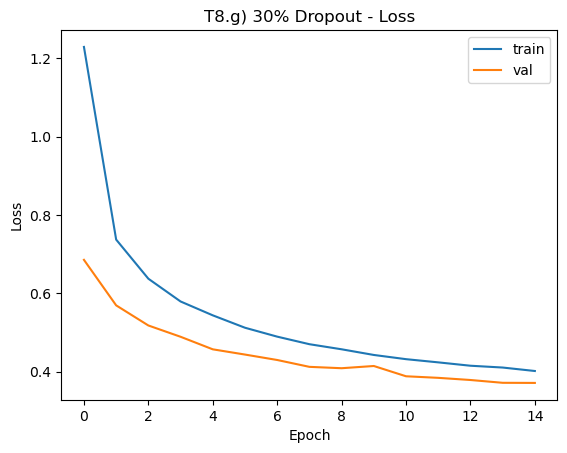

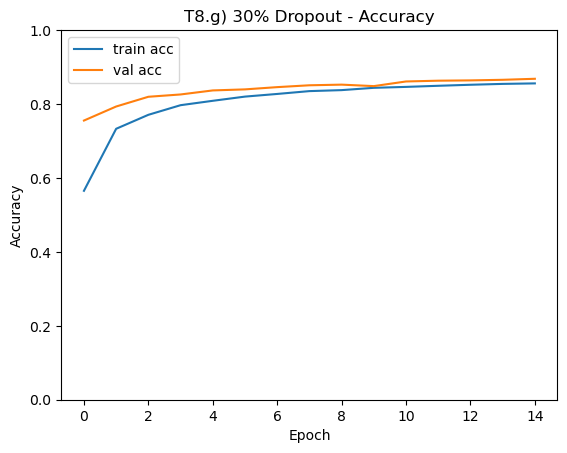

In [17]:
def build_model_with_dropout(activation='relu', dropout_rate=0.3):
    model = Sequential([
        tf.keras.Input(shape=(28, 28)),
        Flatten(),
        Dense(256, activation=activation),
        Dropout(dropout_rate),
        Dense(128, activation=activation),
        Dropout(dropout_rate),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_dropout = build_model_with_dropout(activation='relu', dropout_rate=0.3)

log_dir = "logs/mlp_dropout_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history_dropout.history['loss'], label='train')
plt.plot(history_dropout.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.g) 30% Dropout - Loss')
plt.show()

plt.figure()
plt.plot(history_dropout.history['accuracy'], label='train acc')
plt.plot(history_dropout.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.g) 30% Dropout - Accuracy')
plt.show()

### T8.h) Evaluate the model on the test dataset

We then have to evaluate the model on the test dataset, which is done simply with the evaluate command.

In [31]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test loss for standard model:", test_loss)
print("Test accuracy for standard model:", test_acc)

test_loss_epoch, test_acc_epoch = model2.evaluate(X_test, y_test)
print("Test loss for 70 epochs:", test_loss_epoch)
print("Test accuracy for 70 epochs:", test_acc_epoch)

test_loss_ReLu, test_acc_ReLu = model3.evaluate(X_test, y_test)
print("Test loss for ReLu:", test_loss_ReLu)
print("Test accuracy for ReLu:", test_acc_ReLu)

test_loss_Double, test_acc_Double = model4.evaluate(X_test, y_test)
print("Test loss for double neurons:", test_loss_Double)
print("Test accuracy for double neurons:", test_acc_Double)

test_loss_tanh, test_acc_tanh = model_tanh.evaluate(X_test, y_test)
print("Test loss for tanh:", test_loss_tanh)
print("Test accuracy for tanh:", test_acc_tanh)

test_loss_elu, test_acc_elu = model_elu.evaluate(X_test, y_test)
print("Test loss for elu:", test_loss_elu)
print("Test accuracy for elu:", test_acc_elu)

test_loss_dropout, test_acc_dropout = model_dropout.evaluate(X_test, y_test)
print("Test loss for dropout:", test_loss_dropout)
print("Test accuracy for dropout:", test_acc_dropout)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8576 - loss: 0.3995
Test loss for standard model: 0.3994550406932831
Test accuracy for standard model: 0.8575999736785889
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8789 - loss: 0.3406
Test loss for 70 epochs: 0.3405906558036804
Test accuracy for 70 epochs: 0.8788999915122986
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8669 - loss: 0.3797
Test loss for ReLu: 0.3797443211078644
Test accuracy for ReLu: 0.8669000267982483
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8671 - loss: 0.3717
Test loss for double neurons: 0.37173712253570557
Test accuracy for double neurons: 0.8671000003814697
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8592 - loss: 0.3919
Test loss for tanh: 0.39188897609710693
Test accuracy for tanh: 0.8592000007629395
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8587 - loss: 0.4001
Test loss for elu: 0.4000735580921173
Test accuracy for elu: 0.8586999773979187
313/313 

### T8.i) Save and reload the trained model

The models can be saved and reloaded as shown below. It can then be used like any other model.

In [19]:
#Saving the model
model_dropout.save("fashion_mnist_dropout.keras")

#Loading the model
loaded_model = tf.keras.models.load_model("fashion_mnist_dropout.keras")

## Questions on model training

We have to answer the following questions.

### Q8.a) Explain the purpose of dropout layers?

Dropout randomly turns off a certain fraction of neurons during the training of the model which helps to reduce overfitting since it prevents the model from fitting too much to certain data by constantly changing the considered data. It is therefore forced to learn more robust patterns which better generalizes to useen data. 

### Q8.b) Explain and compare overfitting vs. underfitting

Overfitting and underfitting are both problems which can occur during training. Underfitting means the model is too simple and has not learned enough of the pattern of the data. The model typically performs quite badly even on the training data. Overfitting, on the other hand, results from the model fitting to specifically to the data, often including noise. this typically results in high training accuracy but a much lower validation accuracy.

### Q8.b) What impact does patience have in early stopping?

Patience controls how many epochs the model will keep training after the validation loss or the chosen parameter has stopped improving. In this case it is 5 epochs.

### Q8.c) What happens with a SGD learning rate of smaller values such as 0.001?

With smaller SGD learning rates, the training becomes slower as can be clearly seen by comparing the plots for the original model with a learning rate of 0.01 and the model from T8.b) with a learning rate of 0.001.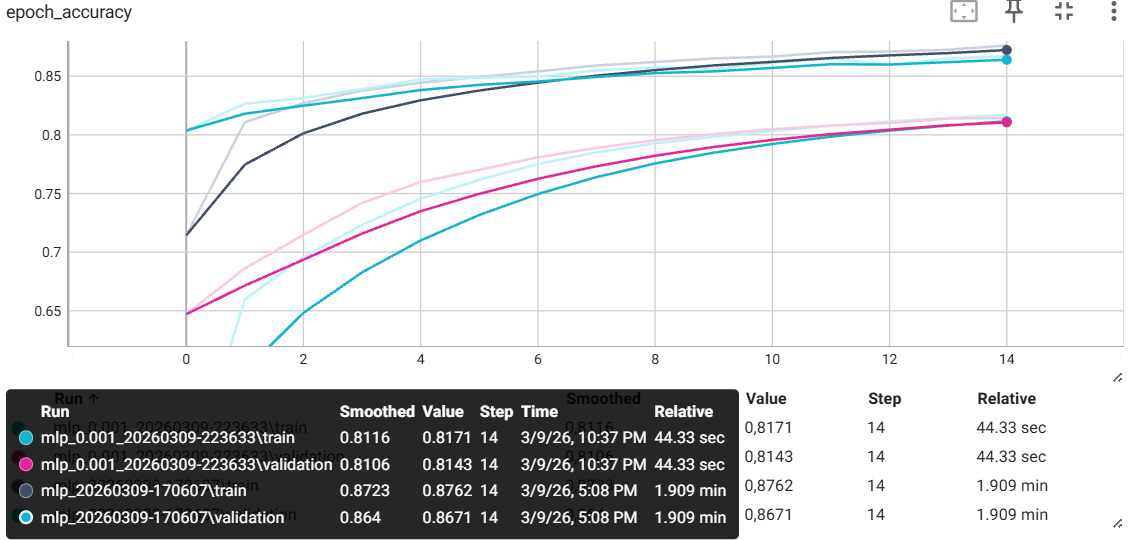 Where it can be seen that the smaller learning rate results in a significantly slower learning process, meaning it will take many more epochs to achieve the same results. It can however also be more stable and the curves for the lower learning rate is generally more stable.


### Q8.d) Compare Adam optimizer with SGD

Comparison of the Adam optimizer with SGD can be done in Tensorboard by plotting the data for SGD and Adam models, both with a learning rate of 0.001.
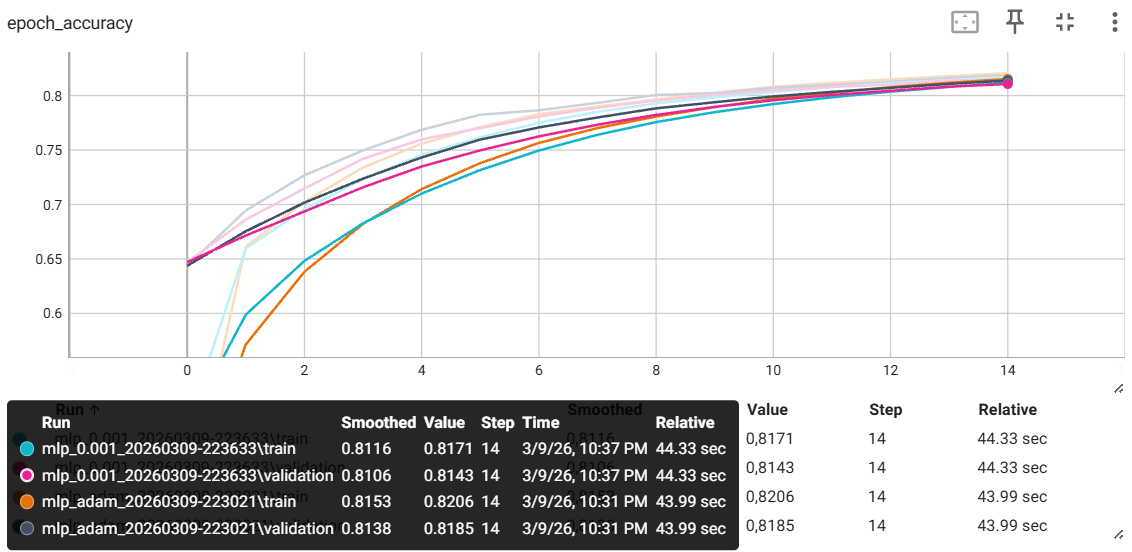 In this case, there is not a big difference but it can still be seen that the Adams models gets a slighly better results and reaches the validation line slightly faster.



## Additional questions for reflection

### Q8.e) Show how to find and calculate the 200.960 parameters in the first layer.

The number of parameters is calculated based input image being 28 by 28, meaning there is 28x28=784 inputs. There is then 256 neurons, which gives 784x256=200704 parameters which summed with the 256 bias inputs gives 200960.

The parameters themselves are computed during the training process by starting with a forward propogation for a prediction. The loss or error is then calculated and backward propogation is then used to find the gradient of the weight to determine which should change. The weights are then calculated as:

$w_1 \rightarrow \mathbf{w}_1 - \delta \frac{\partial L}{\partial w_1}$

The gradients themselves ae calculated based on the chain rule.

$\frac{\partial L}{\partial \hat{w}_1}
=
\frac{\partial L}{\partial F}
\frac{\partial F}{\partial z}
\frac{\partial z}{\partial \hat{w}_1}$

### Q8.f) Which optimizer performed best and why?

The two optimizer performed very similarly in this case but the Adam can still be considered to have performed slighly better based on the previously shown plot from TensorBoard where is has a slighly better end result. The training and validation curves are generally also much closer with adams than with SGD. This is because SGD only takes into account the current gradient while Adam also adjust the weights based on past gradients.

### Q8.g) How did the number of layers affect performance?

To illustrate the effect of the number of layers, the performance of the standard model can be compared to the one with an extra hidden layer in TensorBoard. 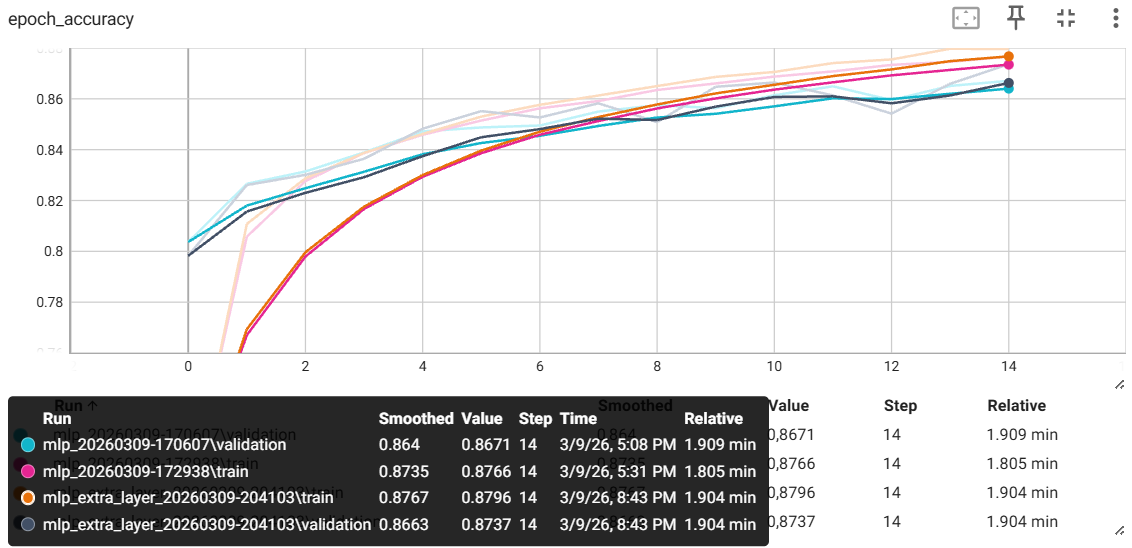 It can then be seen that the extra layers generally improved the performance of the model since both the test and validation accuracy was slighly better.

### Q8.h) Did EarlyStopping help prevent overfitting? (try with more training epochs)

To check whether Earlystopping helped to prevent overfitting, the code from T8.b) was rerun with 70 epoch which resulted in the following plot.
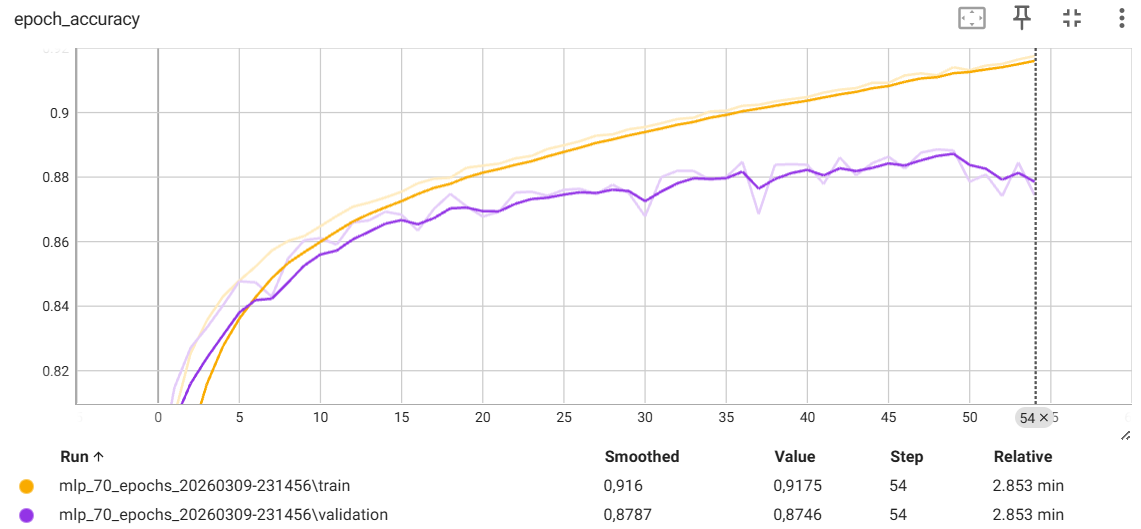 From which we can see that it did not prevent overfitting since we can see the exact characteristics of overfitting where the training accuracy keeps increasing and the validation accuracy is noticeably lower and has stopped increasing.

### Q8.i) What hyperparameters (neurons, layers, dropout..) had the biggest impact?

Based on the evaluated results of T8.h), layers had the biggest impact on the performance and then the numbers of neurons.   